# Basic demonstration of fUSi analysis

This notebook is designed to demonstrate the process of loading functional ultrasound imaging (fUSi) data and associated behavioral metadata. It outlines the steps to preprocess the data, generate statistical parametric maps, and extract time series data from regions of interest (ROIs).

Note that this notebook is built around the dataset collected with UCLA after applying SSEPs and is only running a single run at a time. We'll need fancier approaches to integrate multiple runs, or run more interesting comparisons between multiple conditions


Ultimetly we get something like the figure below, which shows us the stastically significant regions of the fUSi data as well as the corresponding time series data for each ROI.




In [1]:
%load_ext autoreload
%autoreload 2
from nilearn import plotting


import nilearn as nl
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import os
import pandas as pd
import re

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

from ucla_fusi_utils import DirectoryManager
import ucla_fusi_utils as utils


from pathlib import Path
from datetime import datetime, timedelta

from anise.io.load_matlab_dataset import load_data, load_selected_data



In [3]:
# define arguements to specify the data to be processed
base_path=Path('fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/')
sequence = 'seq-RF_generic_rat_sequ_6MHz/'



event_time_offset = -5 # Offset in seconds to apply to stimulus onsets. This can be used to correct for differences between when the instruction is given and when the stimulus is presented.
apply_image_registration=True # If true, we will register the fUSi data to the first frame. If false, we will not register the fUSi data.
time_zone_offset=0

smoothing_fwhm=0.3 #0 spatial smoothing in mm to apply to the data before computing GLM
num_locations=4 # How many ROIs to visualize


dm = DirectoryManager(base_path, sequence)
dm.list_acquisition_directories()
dm.print_paths()

fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/acquisitions/seq-RF_generic_rat_sequ_6MHz/fUSI
Directories in acquisitions path:
    seq-RF_generic_rat_sequ_6MHz
List of all directories in acquisitions path:
    log_file_path: fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/logs/task_1.log
    task_event_file_path: fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/streams/task_1-event_stream.h5
    probe_event_file_path: fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/streams/probe_1-event_stream.h5
    sequence_data_path: fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/acquisitions/seq-RF_generic_rat_sequ_6MHz
    raw_data_path: fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/acquisitions/seq-RF_generic_rat_sequ_6MHz/raw_frame_data
    beamformed_path: fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/fun

In [4]:
# If beamforming and power doppler have not been performed, perform them using the following commands in your terminal (make sure mangrove is activated!)
# Command to execute the mangrove raw data to beamformed conversion
beamform_command =  f'python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'
power_doppler_command =  f'python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'

print(beamform_command)

print(power_doppler_command)

python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/acquisitions/seq-RF_generic_rat_sequ_6MHz"
python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/acquisitions/seq-RF_generic_rat_sequ_6MHz"


In [5]:
# Create the events data structure to create a design matrix
fusi_info=utils.load_fUSi_info(dm.power_doppler_path,num_tissue_components=70)
# task_info=utils.process_task_log(dm.log_file_path,fusi_info,timeoffset=time_zone_offset)
# events=utils.calculate_stimulus_events(task_info)
# Add a specified offset to the event times
# events['onset'] += event_time_offset


task_info = utils.extract_events_from_h5(dm.task_event_file_path)
events=utils.calculate_stimulus_events_caltech_daq(task_info)
probe_events=utils.extract_probe_events_from_h5(dm.probe_event_file_path)
# probe_events.raw_file_name[0]

events['onset'] += event_time_offset


FileNotFoundError: [Errno 2] No such file or directory: 'fUS_data/fUSI_Rat_acquisition/2024-05-30/Rat_002/functional_data/plane1/run-01/acquisitions/seq-RF_generic_rat_sequ_6MHz/power_doppler'

In [5]:

# def match_and_add_filenames(probe_events, fusi_info):
#     # Create a new column in probe_events to store the matched filenames from fusi_info
#     probe_events['fusi_file_name'] = ''

#     # Iterate through each row in probe_events
#     for index, row in probe_events.iterrows():
#         # Extract the filename from the current row in probe_events
#         probe_filename = row['raw_file_name']

#         # Check if this filename exists in the fusi_info DataFrame
#         matched_filenames = fusi_info[fusi_info['Filename'].str.contains(probe_filename[0:-2])]

#         # If there is a match, add the filename to the new column
#         if not matched_filenames.empty:
#             probe_events.at[index, 'fusi_file_name'] = matched_filenames['Filename'].values[0]
    
#     return probe_events
# # Call the function to match and add filenames
# tmp=match_and_add_filenames(probe_events, fusi_info)



Convert the pandas data structure into something importable to nilearn


In [6]:
dm.power_doppler_path
fusi_info

,Filename,Timestamp,Experiment Time,Readable Timestamp
14,ensemble_2024-05-30T22-57-02-626242-pixel_size...,2024-05-30 22:57:02.626242,0.000000,22:57:02.6
47,ensemble_2024-05-30T22-57-19-774006-pixel_size...,2024-05-30 22:57:19.774006,17.147764,22:57:19.7
22,ensemble_2024-05-30T22-57-22-992263-pixel_size...,2024-05-30 22:57:22.992263,20.366021,22:57:22.9
10,ensemble_2024-05-30T22-57-26-248966-pixel_size...,2024-05-30 22:57:26.248966,23.622724,22:57:26.2
31,ensemble_2024-05-30T22-57-29-470854-pixel_size...,2024-05-30 22:57:29.470854,26.844612,22:57:29.4
5,ensemble_2024-05-30T22-57-32-718249-pixel_size...,2024-05-30 22:57:32.718249,30.092007,22:57:32.7
0,ensemble_2024-05-30T22-57-36-034896-pixel_size...,2024-05-30 22:57:36.034896,33.408654,22:57:36.0
27,ensemble_2024-05-30T22-57-42-488223-pixel_size...,2024-05-30 22:57:42.488223,39.861981,22:57:42.4
9,ensemble_2024-05-30T22-57-45-733023-pixel_size...,2024-05-30 22:57:45.733023,43.106781,22:57:45.7
43,ensemble_2024-05-30T22-57-48-951745-pixel_size...,2024-05-30 22:57:48.951745,46.325503,22:57:48.9


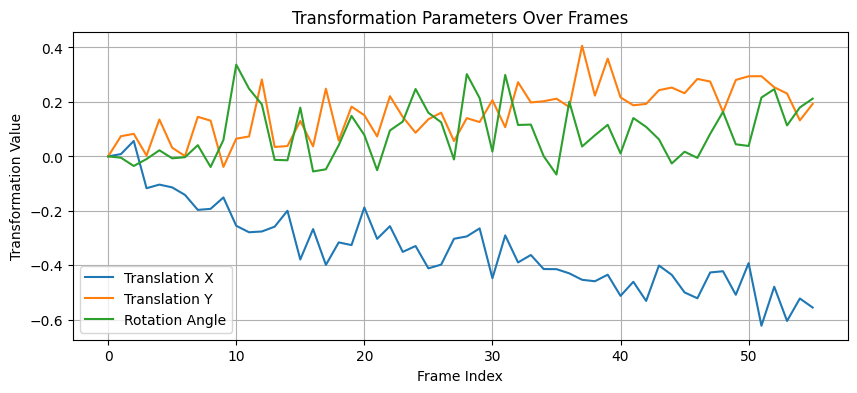

In [7]:


# get fusi data
# frame_indices specifies with power doppler frames to read in. This would be a list e.g. [0,1,2,3...] or just use -1 to specify all
frame_indices = -1  # Specify the frame indices you want to import
fusi_data = utils.get_fusi_frames(dm.power_doppler_path, fusi_info, frame_indices)
fusi_data.shape

plot_transformations=True
if apply_image_registration:
    fusi_data_3d = fusi_data[:, 0, :, :]  # Keep only the first index of the second dimension
    # output_path=str(dm.fUSI_data_path/f"AcquisitionMovie_orig_{sequence}.png") 
    # video = utils.create_video_from_3d_data(fusi_data,output_path=output_path) # this was bugging, need to debug
    # fusi_data_3d=fusi_data_3d-np.min(fusi_data_3d)
    # fusi_data_3d=fusi_data_3d/np.max(fusi_data_3d) *256
    fusi_data_3d_reg,transformations=utils.register_image_stack(fusi_data_3d)
    # fusi_data_3d_reg,transformations=utils.register_ants(fusi_data_3d)
    # Reintroduce the second dimension and tile the data
    fusi_data_3d_reg_expanded = np.expand_dims(fusi_data_3d_reg, axis=1)  # Add a singleton dimension at axis 1
    # output_path=str(dm.fUSI_data_path/f"AcquisitionMovie_reg_{sequence}.png")
    # video = utils.create_video_from_3d_data(fusi_data,output_path=output_path)
    # display(video)
    fusi_data = np.tile(fusi_data_3d_reg_expanded, (1, 2, 1, 1))
    if plot_transformations:
        plt.figure(figsize=(10, 4))
        plt.plot(transformations[0, :], label='Translation X')
        plt.plot(transformations[1, :], label='Translation Y')
        plt.plot(transformations[2, :]*180/np.pi, label='Rotation Angle')

        
        plt.title('Transformation Parameters Over Frames')
        plt.xlabel('Frame Index')
        plt.ylabel('Transformation Value')
        plt.legend()
        plt.grid(True)
        plt.show()



                                             Filename  \
14  ensemble_2024-05-30T22-57-02-626242-pixel_size...   
47  ensemble_2024-05-30T22-57-19-774006-pixel_size...   
22  ensemble_2024-05-30T22-57-22-992263-pixel_size...   
10  ensemble_2024-05-30T22-57-26-248966-pixel_size...   
31  ensemble_2024-05-30T22-57-29-470854-pixel_size...   
5   ensemble_2024-05-30T22-57-32-718249-pixel_size...   
0   ensemble_2024-05-30T22-57-36-034896-pixel_size...   
27  ensemble_2024-05-30T22-57-42-488223-pixel_size...   
9   ensemble_2024-05-30T22-57-45-733023-pixel_size...   
43  ensemble_2024-05-30T22-57-48-951745-pixel_size...   
25  ensemble_2024-05-30T22-57-52-230097-pixel_size...   
44  ensemble_2024-05-30T22-57-55-458643-pixel_size...   
23  ensemble_2024-05-30T22-57-58-677095-pixel_size...   
8   ensemble_2024-05-30T22-58-01-941879-pixel_size...   
55  ensemble_2024-05-30T22-58-05-203742-pixel_size...   
49  ensemble_2024-05-30T22-58-11-707312-pixel_size...   
52  ensemble_2024-05-30T22-58-1

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5595/3149465804.py:23: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



<Figure size 640x480 with 0 Axes>

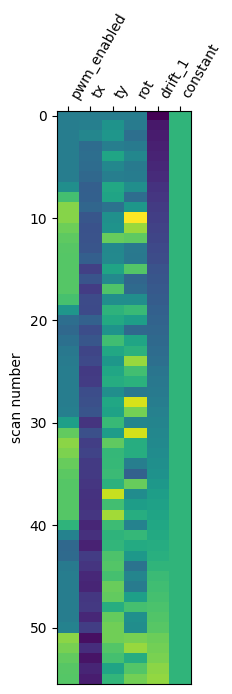

In [8]:

hrf_model = "glover"
if apply_image_registration:
    design_matrix = make_first_level_design_matrix(
        fusi_info['Experiment Time'] ,
        events,
        drift_model="polynomial",
        drift_order=1,
        add_regs=transformations.transpose(),
        add_reg_names=["tx","ty","rot"],
        hrf_model=hrf_model,
    )
else:
    design_matrix = make_first_level_design_matrix(
        fusi_info['Experiment Time'] ,
        events,
        drift_model="polynomial",
        drift_order=1,
        hrf_model=hrf_model,
    )

fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()

print(fusi_info)
print(task_info)
print(events)

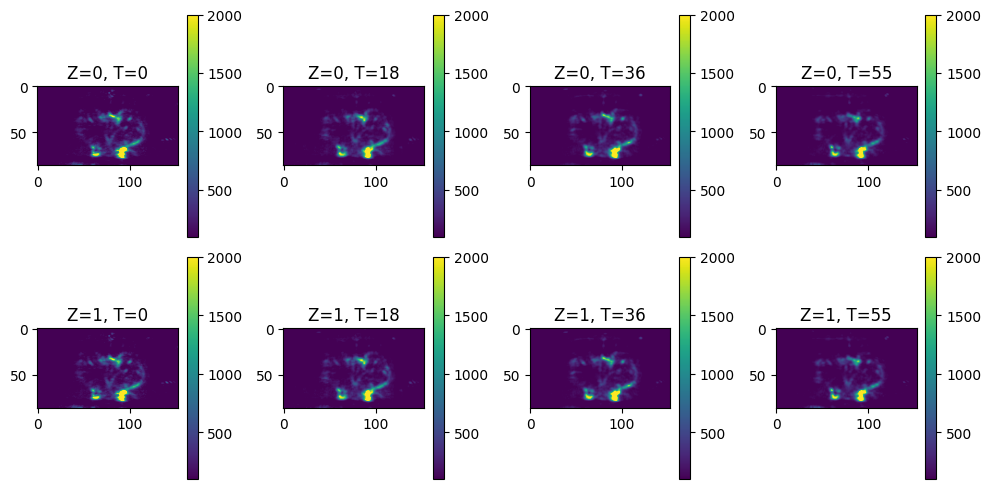

In [9]:
# Plot the data, make sure nothing crazy is happening, in particular, as I am mocking a 3D scan to play nice with nilearn, we need to make sure the data is in the right shape and the info across the second dimension is simply a copy
import matplotlib.pyplot as plt
# visualize to ensure we are getting what we think we should be getting!

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))  # 2 rows for Z dimension, 4 columns for T dimension
for z_dim in range(2):  # Loop over the Z dimension (1 dimension)
    for t_index, t_dim in enumerate(np.linspace(0, fusi_data.shape[3] - 1, 4, dtype=int)):  # Sample 4 equally spaced indices along the T dimension
        ax = axs[z_dim, t_index]
        # img_plot = ax.imshow(np.flip(fusi_data[:, z_dim, :, t_dim].transpose(), axis=0), aspect='equal', vmin=0, vmax=255)
        img_plot = ax.imshow(np.flip(fusi_data[:, z_dim, :, t_dim].transpose(), axis=0), aspect='equal', vmin=100, vmax=2000)

        ax.set_title(f'Z={z_dim}, T={t_dim}')
        plt.colorbar(img_plot, ax=ax)

plt.tight_layout()
plt.show()

Data shape is (153, 2, 86)


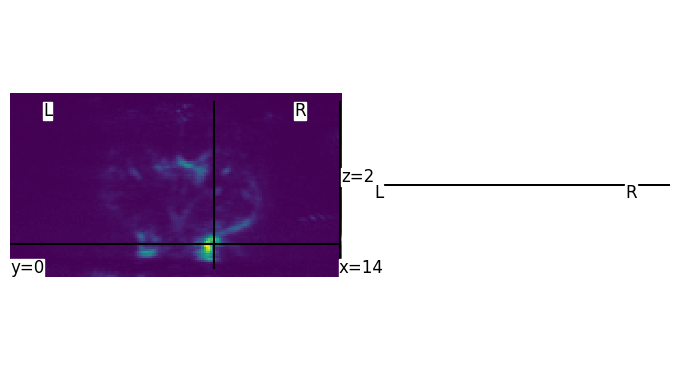

In [10]:
# quick sanity check that conversion to nifti / save/load are working.
from nilearn import image
import nibabel as nib

affine=np.diag([.15,.15,.15,0])
pd=np.array(fusi_data[:,:,:,0])
nifti_img = nib.Nifti1Image(pd, affine)
nifti_img.to_filename(dm.fUSI_data_path/"fUSi_data.nii.gz")
tmp=image.load_img(dm.fUSI_data_path/"fUSi_data.nii.gz")
print(f'Data shape is {tmp.shape}')
plotting.plot_img(tmp)

In [11]:
from nilearn.signal import butterworth


affine=np.diag([.15,.15,.15,0])
# pd=np.array(fusi_data)
def boxcar_smooth(data, window_size):
    if window_size>0:
        temp_smooth_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(data[:, :, :, start_index:end_index], axis=3)
    else:
        smoothed_data=data
    return smoothed_data

window_size = 0  # Number of time points for smoothing
pd = boxcar_smooth(fusi_data, window_size)
nifti_img = nib.Nifti1Image(pd, affine)
nifti_img.to_filename(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data=image.load_img(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data.shape

(153, 2, 86, 56)

In [23]:
# Define the smoothing function
def temporal_smoothing(data, window_size):
    # Initialize the smoothed data array
    temp_smooth_data = np.zeros_like(data)
    
    # Apply the smoothing
    for t in range(data.shape[3]):
        start_index = max(0, t - window_size // 2)
        end_index = min(data.shape[3], t + window_size // 2 + 1)
        temp_smooth_data[:, :, :, t] = np.mean(data[:, :, :, start_index:end_index], axis=3)
    
    return temp_smooth_data

# Set the window size for smoothing
smoothing_window_size = 1  # This can be adjusted as needed

# Apply the smoothing function to the data
temp_smooth_data = temporal_smoothing(fusi_data, smoothing_window_size)

# Convert the smoothed data back into a Nifti image
smoothed_nifti_img = nib.Nifti1Image(temp_smooth_data, affine)
smoothed_nifti_img.to_filename(dm.fUSI_data_path/"smoothed_fUSi_data.nii.gz")
smoothed_nifti_data=image.load_img(dm.fUSI_data_path/"smoothed_fUSi_data.nii.gz")
smoothed_nifti_data.shape


(153, 2, 86, 56)

In [24]:
contrast_matrix = np.eye(design_matrix.shape[1])
basic_contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}
basic_contrasts

{'pwm_enabled': array([1., 0., 0., 0., 0., 0.]),
 'tx': array([0., 1., 0., 0., 0., 0.]),
 'ty': array([0., 0., 1., 0., 0., 0.]),
 'rot': array([0., 0., 0., 1., 0., 0.]),
 'drift_1': array([0., 0., 0., 0., 1., 0.]),
 'constant': array([0., 0., 0., 0., 0., 1.])}

In [25]:
from nilearn.glm.first_level import FirstLevelModel
print("Fitting a GLM")
fmri_glm = FirstLevelModel(minimize_memory=False,mask_img=False,smoothing_fwhm=smoothing_fwhm,standardize=True)
fmri_glm = fmri_glm.fit(nifti_data, design_matrices=design_matrix)

Fitting a GLM


Computing contrasts
	contrast id: pwm_enabled


/Users/clairenastaskin/miniforge3/envs/Anise/lib/python3.9/site-packages/nilearn/plotting/find_cuts.py:315: UserWarning:

Too many cuts requested for the data: n_cuts=7, data size=2.



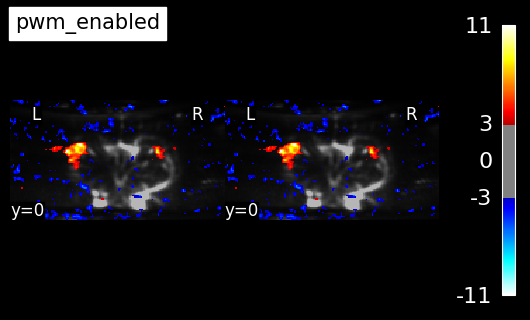

	contrast id: tx


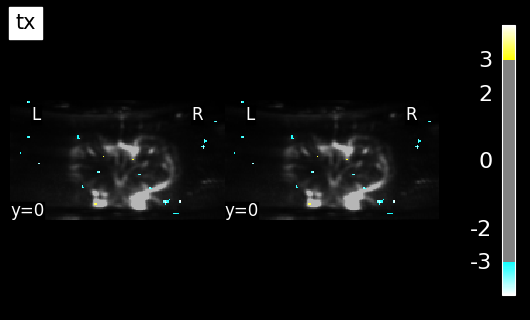

	contrast id: ty


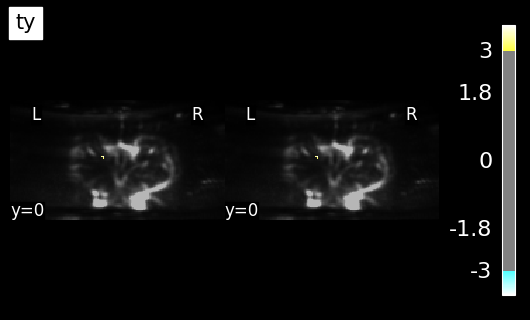

	contrast id: rot


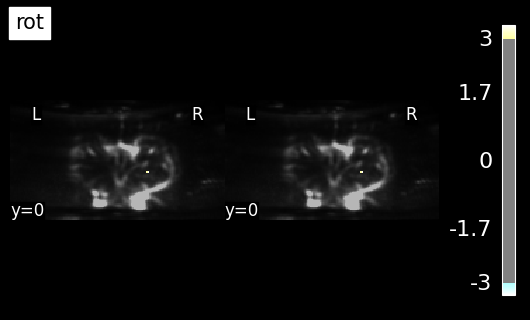

	contrast id: drift_1


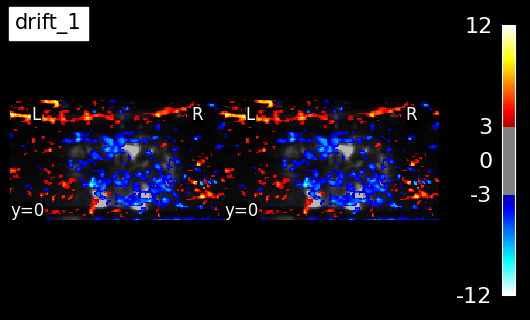

	contrast id: constant


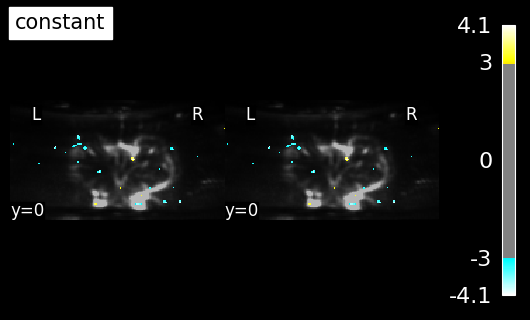

In [26]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img, new_img_like

nifti_data = smoothed_nifti_data # if we want to use the smooth data

print("Computing contrasts")
mean_image = mean_img(nifti_data) # mean doppler image

# Increase the intensity of the mean_image (doppler)
data = mean_image.get_fdata()
scaled_data = (data - data.min()) / (data.max() - data.min())  # Normalize the data to 0-1
enhanced_data = scaled_data * 4  # Scale the normalized data to increase intensity
enhanced_data[enhanced_data > 1] = 1  # Clip values to maintain them within [0, 1]

# Create a new Nifti image with the enhanced data
enhanced_mean_image = new_img_like(mean_image, enhanced_data)

# Iterate on contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat") # 
    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fMRI image
    # a threshold of 3.0 is used, more sophisticated choices are possible
    plotting.plot_stat_map(
        z_map,
        bg_img=enhanced_mean_image,
        threshold=3,        

        display_mode="y",        
        black_bg=True,        
        title=contrast_id,
    )
    plotting.show()

In [27]:
# Save the z_maps as .mat files

import nibabel as nib
from scipy.io import savemat
from pathlib import Path

# Assuming fmri_glm and basic_contrasts are already defined and used as shown previously
for contrast_id, contrast_val in basic_contrasts.items():
    print(f"Processing contrast id: {contrast_id}")
    # Compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="z_score")
    # Load the z_map data as an array
    z_map_data = z_map.get_fdata()
    # If you need a 2D array combining all slices (e.g., 177x198), you can reshape:
    if z_map_data.shape[2] * z_map_data.shape[1] == 198:  # Example condition for reshaping
        combined_slices = z_map_data.reshape(z_map_data.shape[0], -1)
        save_path = Path(base_path) / 'acquisitions' / sequence / 'functional_analysis' / f"{contrast_id}_z_map_combined.mat"
        savemat(save_path, {'z_map': combined_slices})
        print(f"Saved {save_path}")

Processing contrast id: pwm_enabled
Processing contrast id: tx
Processing contrast id: ty
Processing contrast id: rot
Processing contrast id: drift_1
Processing contrast id: constant


# Plot time series for ROI response and stimulus regressor

Identify ROIs using an automated clustering approach. Extract the time series for each ROI. Plot the time series and corresponding locations.



array([17.147764,  3.218257,  3.256703,  3.221888,  3.247395,  3.316647,
        6.453327,  3.2448  ,  3.218722,  3.278352,  3.228546,  3.218452,
        3.264784,  3.261863,  6.50357 ,  3.298449,  3.219359,  3.279549,
        3.247385,  3.21852 ,  3.230316,  3.296274,  3.219637,  3.26619 ,
        6.523584,  3.279807,  3.238551,  3.232866,  3.316939,  3.286735,
        3.220902,  3.282173,  3.29709 ,  3.222702,  3.30308 ,  6.494825,
        6.566522,  3.230353,  3.26462 ,  3.240686,  3.226288,  3.239514,
        3.258066,  6.515374,  6.515773,  3.237397,  3.327519,  3.22066 ,
        3.28987 ,  3.267605,  9.742241,  3.241576,  3.244524,  6.516098,
        3.314199])

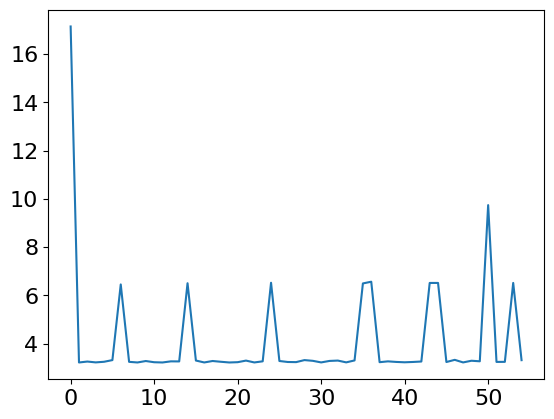

In [28]:
a=fusi_info["Experiment Time"].values
import numpy as np
diff_a = np.diff(a)
a
# type(a)
plt.plot(diff_a)
diff_a
# diff_a


In [29]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table

num_locations=2 # How many ROIs to visualize

# Find ROIs by identifying the locations that show a significant response to the stimulus
mean_image = mean_img(nifti_data)
z_map = fmri_glm.compute_contrast(basic_contrasts['pwm_enabled'], output_type="stat")
# z_map = fmri_glm.compute_contrast(basic_contrasts['drift_1'], output_type="stat")
table = get_clusters_table(z_map, stat_threshold=2.5, cluster_threshold=10)
table.set_index("Cluster ID", drop=True)
table.head()

# get the num_locations largest clusters' max x, y, and z coordinates
coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
# coords = np.vstack([coords, [10.45000061,  0.        , 18.40000045]])

print(coords)



# Now use the ROIs to extract the time series 
masker = NiftiSpheresMasker(coords)
standardize="zscore" # zscore psc
masker = NiftiSpheresMasker(
    coords,
    radius=smoothing_fwhm,
    detrend=True,
    standardize="psc", # standardize, zscore psc
    # low_pass=0.1,
    # high_pass=0.01,
    t_r=3,
    # memory="nilearn_cache",
    memory_level=1,
    verbose=0,
)

real_timeseries = masker.fit_transform(nifti_data)
# predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])
predicted_timeseries = np.tile(design_matrix['pwm_enabled'].values, (real_timeseries.shape[1], 1)).T


[[ 6.00000024  0.          7.35000029]
 [15.60000062  0.          7.20000029]]


In [30]:
from sklearn.metrics import r2_score

# Calculate the R-squared value for each ROI
r_squared_values = []
for i in range(real_timeseries.shape[1]):
    r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
    r_squared_values.append(r_squared)

# Display the R-squared values
print("R-squared values for each ROI:")
for idx, r2 in enumerate(r_squared_values):
    print(f"ROI {idx + 1}: {r2:.3f}")

R-squared values for each ROI:
ROI 1: 0.046
ROI 2: 0.042


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5595/4007118083.py:44: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



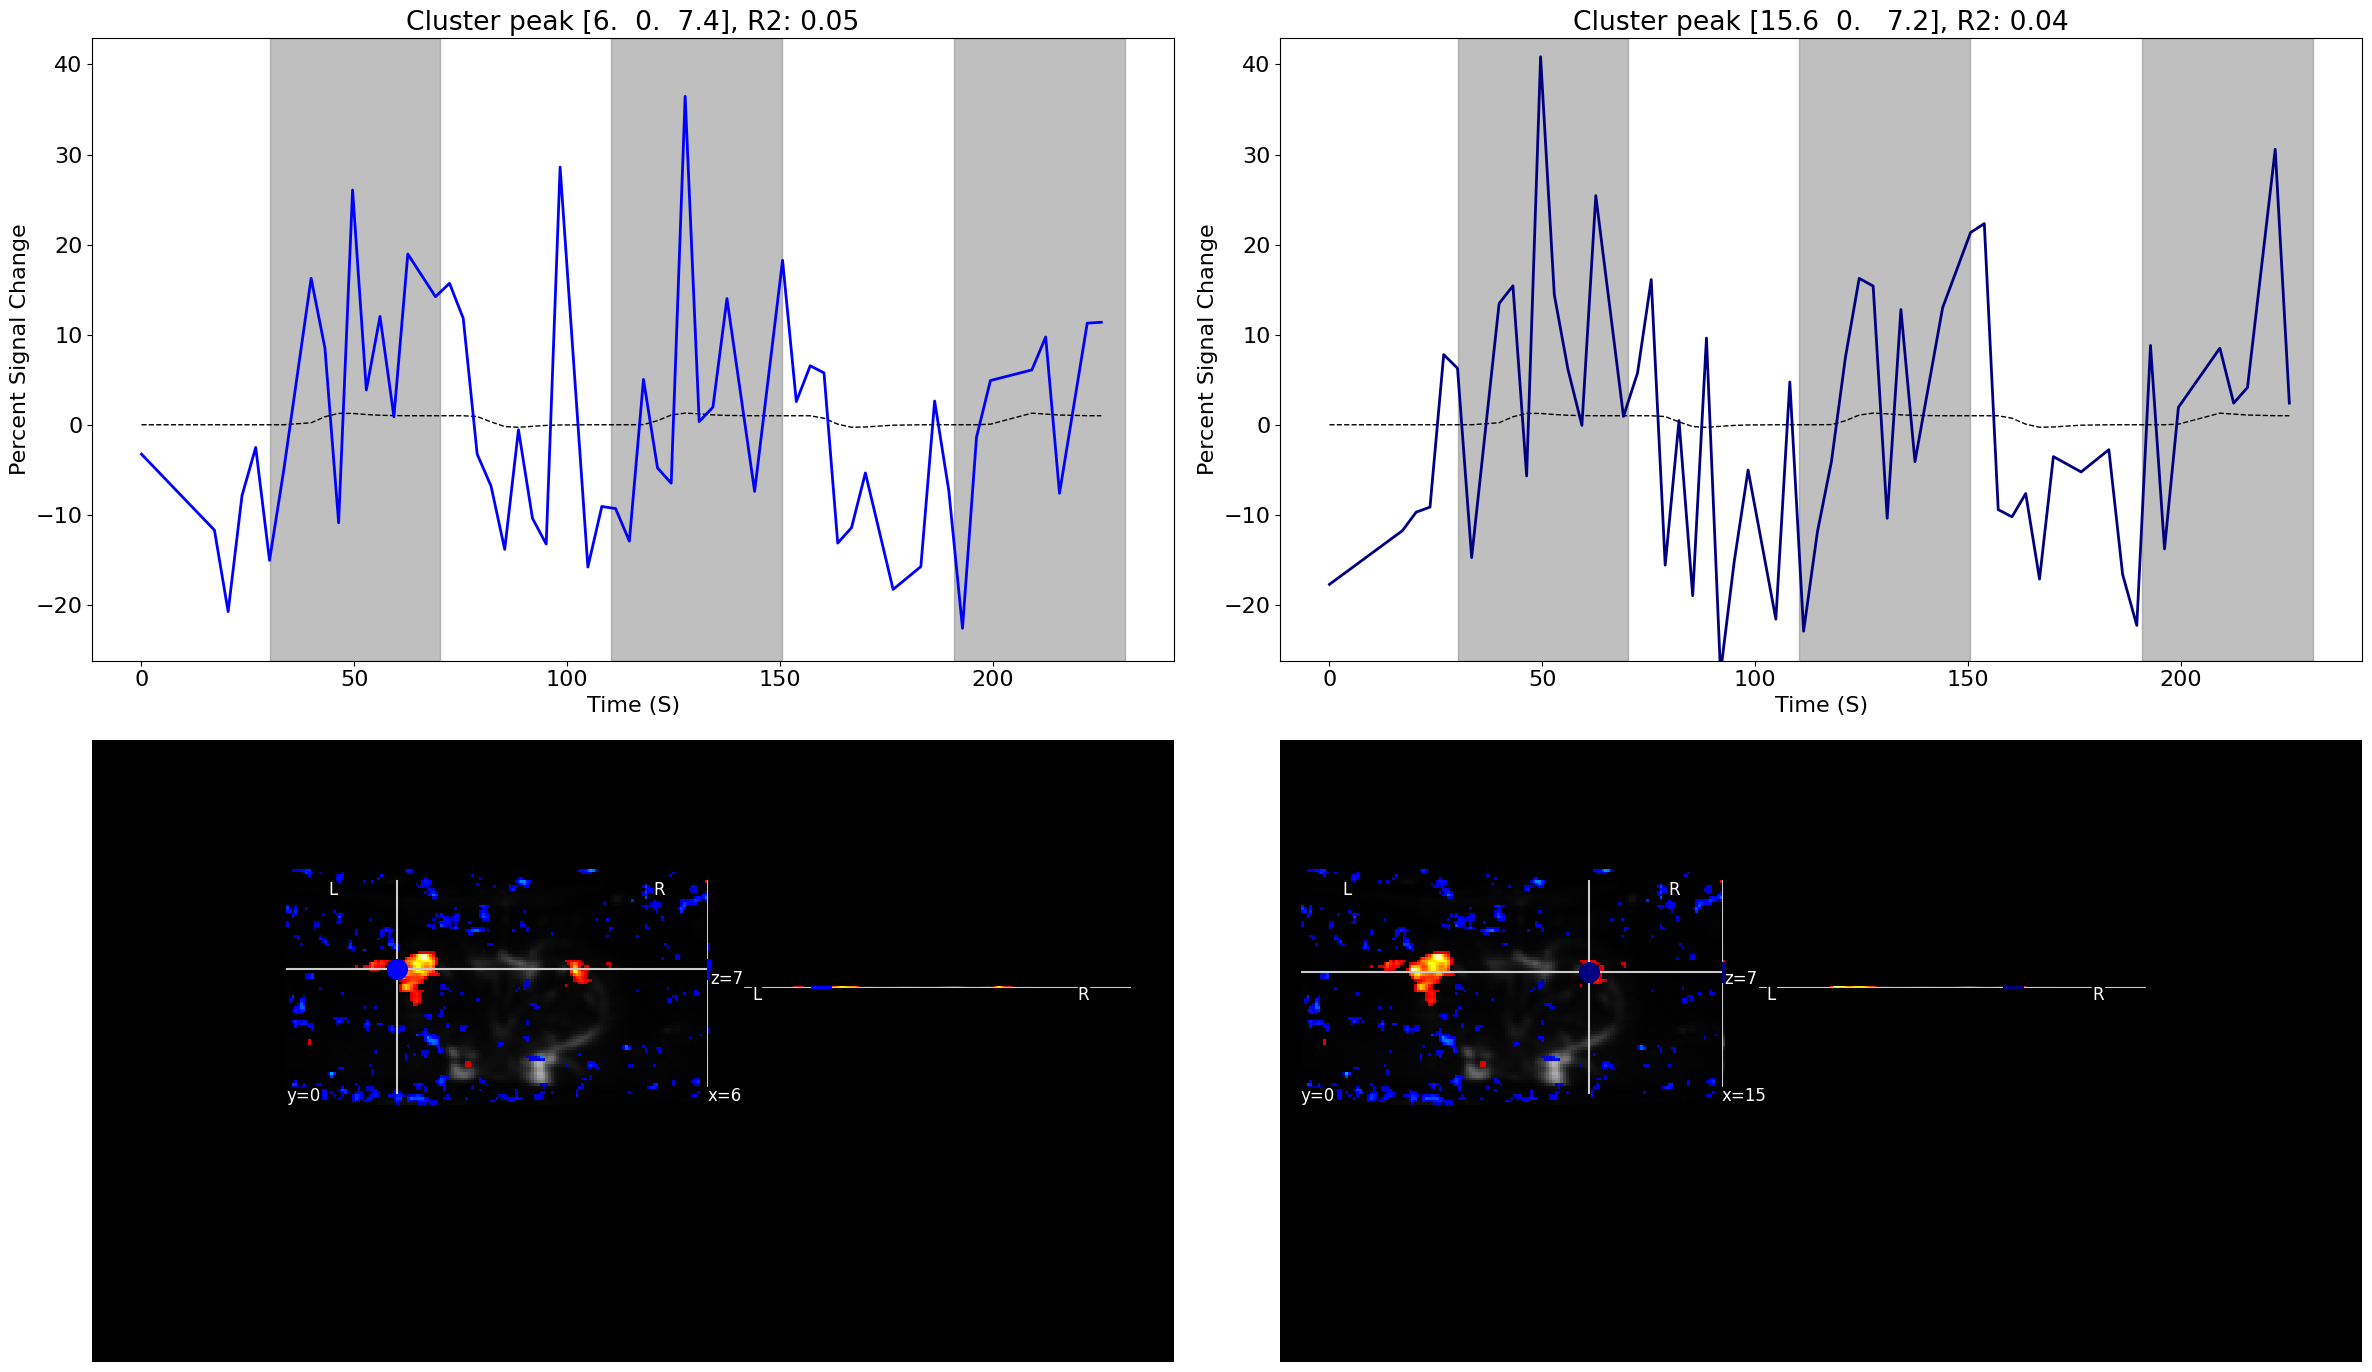

In [31]:
import matplotlib.pyplot as plt
from nilearn import plotting
import matplotlib as mpl

# Assuming all necessary variables like `real_timeseries`, `predicted_timeseries`, `fusi_info`, `events`, etc. are already defined
mpl.rcParams.update({'font.size': 16})  # You can adjust the size as needed

colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
N = real_timeseries.shape[-1]
fig1, axs1 = plt.subplots(2, N, figsize=(24, 14))

mx = real_timeseries.max() + 0.05 * real_timeseries.max()
mn = real_timeseries.min() - 0.05 * real_timeseries.min()

for i in range(N):
    # Time series plot
    axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}")
    axs1[0, i].plot(fusi_info['Experiment Time'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    axs1[0, i].plot(fusi_info['Experiment Time'], real_timeseries[:, i], c=colors[i], lw=2)
    axs1[0, i].set_xlabel("Time (S)")
    axs1[0, i].set_ylim(mn, mx)
    if masker.standardize == "psc":
        axs1[0, i].set_ylabel('Percent Signal Change')
    else:
        axs1[0, i].set_ylabel("Signal intensity")

    # Highlight regions of time described by the onsets and durations in events
    for onset, duration in zip(events['onset'], events['duration']):
        axs1[0, i].axvspan(onset + event_time_offset, onset + duration + event_time_offset, color='gray', alpha=0.5)

    # Statistical map plot
    display = plotting.plot_stat_map(
        z_map,
        cut_coords=coords[i],
        threshold=3,
        figure=fig1,
        axes=axs1[1, i],
        display_mode="ortho",
        colorbar=False,
        bg_img=mean_image,
    )
    display.add_markers([coords[i]], marker_color=colors[i], marker_size=200)

plt.tight_layout()
plt.show()

In [32]:
onsets = events['onset'].values
durations = events['duration'].values
real_timeseries = real_timeseries.reshape(real_timeseries.shape[0], real_timeseries.shape[1], 1)

from scipy.io import savemat

# Assuming 'onsets' and 'durations' are already defined as numpy arrays
savemat(base_path / 'acquisitions' / sequence / 'functional_analysis' / 'onsets.mat', {'onsets': onsets})
savemat(base_path / 'acquisitions' / sequence / 'functional_analysis' / 'durations.mat', {'durations': durations})
savemat(base_path / 'acquisitions' / sequence / 'functional_analysis' / 'real_timeseries.mat', {'real_timeseries': real_timeseries})

from scipy.io import savemat



OSError: Reader needs file name or open file-like object

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

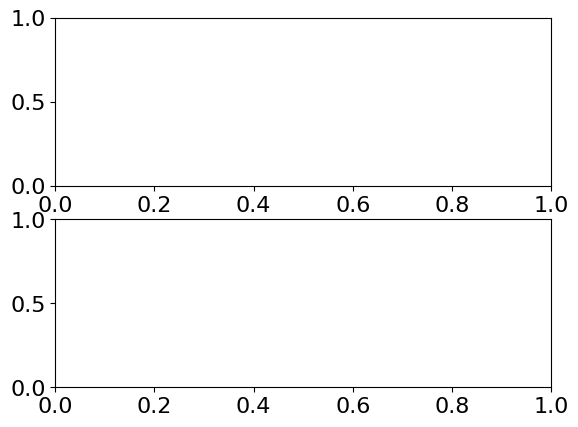

In [ ]:
# And finaly, plot the time series for each ROI and the corresponding location of each ROI
# colors for each of the clusters
colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
N=real_timeseries.shape[-1]
fig1, axs1 = plt.subplots(2, N)

# get plot limits, common across all axis
mx=real_timeseries.max()+0.05*real_timeseries.max()
mn=real_timeseries.min()+0.05*real_timeseries.min()

for i in range(N):
    # plotting time series
    axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
    if masker.standardize != "psc":
        axs1[0, i].plot(fusi_info['Experiment Time'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    # axs1[0, i].plot(fusi_info['Experiment Time'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    # axs1[0, i].plot(fusi_info['Experiment Time'], design_matrix['Stimulus on'], c="k", ls="--", lw=1)
    axs1[0, i].plot(fusi_info['Experiment Time'], real_timeseries[:, i], c=colors[i], lw=2)
    axs1[0, i].set_xlabel("Time (S)")

    if masker.standardize == "psc":
        axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
    else:
        axs1[0, i].set_ylabel("Signal intensity", labelpad=0)

    # plotting image below the time series
    # Highlight regions of time described by the onsets and durations in events
    # Assuming 'events' is a DataFrame with columns 'onset' and 'duration' for stimulus events
    for onset, duration in zip(events['onset'], events['duration']):
        axs1[0, i].axvspan(onset+event_time_offset, onset + duration+event_time_offset, color='gray', alpha=0.5)
    
    roi_img = plotting.plot_stat_map(
        z_map,
        cut_coords=coords[i],
        threshold=3,
        figure=fig1,
        axes=axs1[1, i],
        display_mode="y",
        colorbar=False,
        bg_img=mean_image,
    )
    
    axs1[0, i].set_ylim(mn, mx)
    roi_img.add_markers([coords[i]], colors[i], 200)
fig1.set_size_inches(24, 14)

# fig1.savefig(dm.fUSI_data_path/f"ROI_time_series_{sequence}.png")

